# Coupled RIME-X x lifetime exposure

In an environment where both rimeX and dem4cli are installed the following notebook will run

You will need the MAGICC ensemble data and the quantile maps to run the RIME-X part of the analysis (specify filepath in code)

You will need the UNWPP life expectancy data to run the lifetime exopsure part of the analysis (specify file path in code)

Questions/open points (from Rosa):
- extension post 2100:
    - for the SCM part (scenario > GMT) this can be done by using the extended CMIP7 scenarios data and getting the warming ensemble from MAGICC/FaIR from this? 
    - keep pop-weighing the same past 2100 - might have to slightly modify lifetime exposure fxn to accomodate for this
- 

contact: quentin.lejeune@vub.be, rosa.pietroiusti@vub.be (+Niklas Schwind, Raffaela Langer @IIASA)

In [ ]:
import glob, sys, os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# import fxns from rimeX
from rimeX.preproc.quantilemaps import make_quantilemap_prediction#, make_timesensitive_quantilemap_prediction
from rimeX.emulator import recombine_gmt_ensemble, load_magicc_ensemble


# import fxns from dem4cli
from dem4cli.population_demographics import load_unwpp_lifeexpectancy, get_life_expectancies
from dem4cli.lifetime_exposure import calc_lifetime_exposure_rimex


In [2]:

import numpy as np
import xarray as xr
import pandas as pd
import sys, os, re
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [3]:
def make_timesensitive_quantilemap_prediction(quantile_maps, gmt, region, indicator, samples=100, seed=42, quantiles=[0.5, .05, .95], mode="deterministic", clip=False, skipna=False):
    """Make a prediction form the quantile map for a given global mean temperature using different quantile_maps per year. You can use this function to account for e.g. timesensitive weighting schemes in your emulation appearing when socioeconomic conditions change

    Parameters
    ----------
    quantile_maps : dictionary with all years as keys and paths to xr.DataArrays produced by make_quantile_map_array as values.

    gmt : pandas DataFrame for the global mean temperature, with years as index and ensemble members as columns

    region: string, region to make the prediction for

    indicator: string, indicator to make the prediction for

    samples : number of samples to draw (default: 100)

    seed : random seed

    quantiles : quantiles to compute (default: [0.5, .05, .95])
        if None, all ensemble members are returned

    mode : {"deterministic", "factorial", "montecarlo"}
        - "deterministic" (the default): gmt is resampled deterministically
        - "montecarlo" : gmt is simply resampled (may speed-up the computation at the cost of some loss of precision)
        - "factorial" : gmt is combined with the quantile map in a factorial way
            The total number of samples is then samples * gmt.shape[1]
        Note the impact distribution is always resampled in a deterministic way

    clip : bool
        if True, clip the GMT data to the range of the quantile map, otherwise fill with NaNs
        False by default

    skipna : bool
        if True, skip NaN values in the quantiles calculation (default: False)
        can be useful if clip is set to False

    Returns
    -------
    sampled_maps : xr.DataArray with dimensions year, sample
    """
    predictions = []
    
    for year, quantile_map_path in quantile_maps.items():
        
        relevant_gmt = gmt.loc[[year]]
        
        with xr.open_dataset(quantile_map_path) as ds:
            relevant_quantile_map = ds[indicator].sel(region=region).load()
        
        prediction = make_quantilemap_prediction(relevant_quantile_map, relevant_gmt, samples=samples, seed=seed, quantiles=quantiles, mode=mode, clip=clip, skipna=skipna)
        
        predictions.append(prediction)

    sampled_maps = xr.concat(predictions, dim = 'year')
    
    return sampled_maps

#### Check a RIME-X input data

One file per region, per warming level, per quantile, per indicator

In [81]:
path = r'C:\Users\rpietroi\Documents\repos-local\data-rimex\pdrive\projects\icigroup\RIME-X-Lifetime-Exposure/isimip3\running-21-years\quantilemaps_regional_admin\HI-caution-QDM-v1\AGO\HI-caution-QDM-v1_annual_ago_historical_1950_popweight_eq.nc'

ds = xr.open_dataset(path)

ds

<xarray.Dataset> Size: 55kB
Dimensions:            (warming_level: 66, quantile: 101, region: 1)
Coordinates:
  * warming_level      (warming_level) float64 528B 0.0 0.1 0.2 ... 6.3 6.4 6.5
  * quantile           (quantile) float64 808B 0.0 0.01 0.02 ... 0.98 0.99 1.0
  * region             (region) <U3 12B 'AGO'
Data variables:
    HI-caution-QDM-v1  (warming_level, quantile, region) float64 53kB ...

##### Function to load scenario data

In [53]:
PATH = os.path.join('..', '..', 'data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/')
magicc_files = f'{PATH}NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv'
scenario = load_magicc_ensemble(file=magicc_files, projection_baseline=None,projection_baseline_offset=None).reindex(np.arange(1950,2100+1,1))

[13:45:21 | rimeX | INFO] Load MAGICC ensemble ..\..\data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None


In [54]:
#INDICATOR = 'HI-extreme-caution-QDM-v1' - loading

INDICATOR = 'HI-caution-QDM-v1'

COUNTRY = 'IND'
SEASON = 'annual'

PATH=r"C:\Users\rpietroi\Documents\repos-local\data-rimex\pdrive\projects\icigroup\RIME-X-Lifetime-Exposure"

weightings = {}
for i in range(150):
    if 1950+i <= 2025:
        weightings[1950+i] = f'historical_{1950+i}_popweight'
    else:
        weightings[1950+i] = f'ssp2_{1950+i}_popweight'

quantile_maps = {year: f'{PATH}/isimip3/running-21-years/quantilemaps_regional_admin/{INDICATOR}/{COUNTRY}/{INDICATOR}_{SEASON}_{COUNTRY.lower()}_{weighting}_eq.nc' for year,weighting in weightings.items()}

prediction = make_timesensitive_quantilemap_prediction(quantile_maps, scenario, region = COUNTRY, indicator = INDICATOR, samples = 5000)

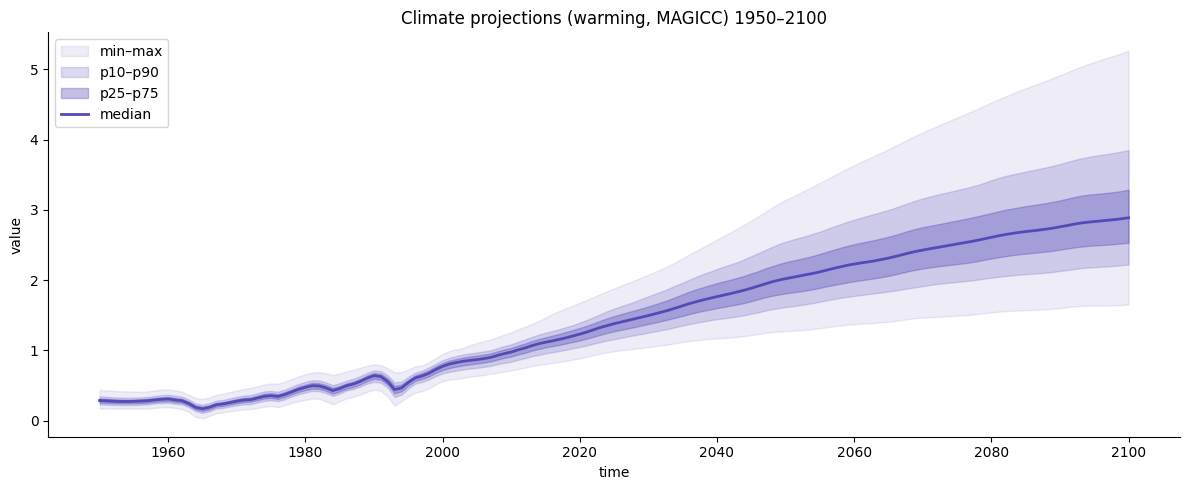

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ensemble(df, title="Ensemble forecast", figsize=(12, 5)):
    idx = df.index
    vals = df.values

    median = np.median(vals, axis=1)
    p10, p25, p75, p90 = np.percentile(vals, [10, 25, 75, 90], axis=1)
    mn, mx = vals.min(axis=1), vals.max(axis=1)

    color = "#534AB7"

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(idx, mn, mx, alpha=0.10, color=color, label="min–max")
    ax.fill_between(idx, p10, p90, alpha=0.20, color=color, label="p10–p90")
    ax.fill_between(idx, p25, p75, alpha=0.35, color=color, label="p25–p75")
    ax.plot(idx, median, color=color, linewidth=2, label="median")

    ax.set_title(title)
    ax.set_xlabel(df.index.name or "time")
    ax.set_ylabel("value")
    ax.legend(loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_ensemble(scenario, title="Climate projections (warming, MAGICC) 1950–2100")

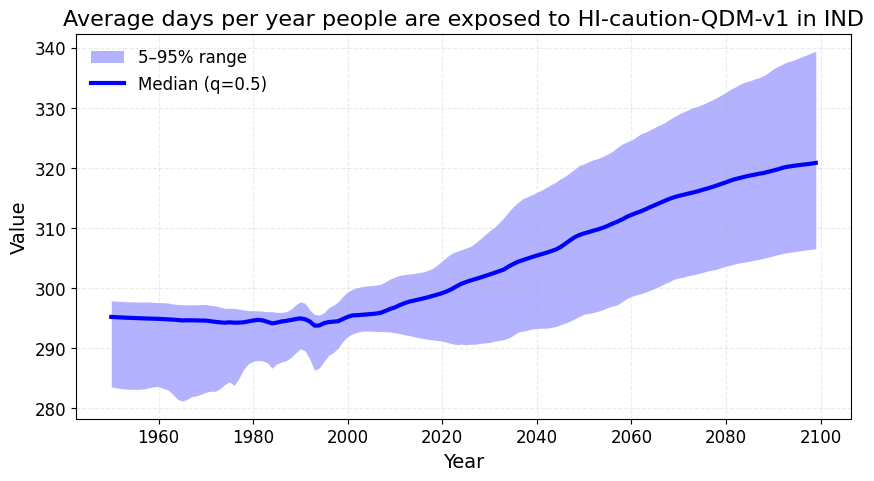

In [55]:
import matplotlib.pyplot as plt
#import seaborn as sns

def plot_quantile_timeseries(
    da,
    central_quantile=0.5,
    lower_quantile=0.05,
    upper_quantile=0.95,
    ax=None,
    color=None,
    label=None,
    figsize=(10, 5),
    title=None,
):
    """
    Plot a time series with quantile uncertainty shading.

    Returns
    -------
    fig, ax
    """

    if color is None:
        color = 'blue'
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    years = da["year"].values
    central = da.sel(quantile=central_quantile).values
    lower = da.sel(quantile=lower_quantile).values
    upper = da.sel(quantile=upper_quantile).values

    # Uncertainty band
    ax.fill_between(
        years,
        lower,
        upper,
        color=color,
        alpha=0.3,
        linewidth=0,
        label=f"{int(lower_quantile*100)}–{int(upper_quantile*100)}% range",
    )

    # Central line
    ax.plot(
        years,
        central,
        color=color,
        linewidth=3,
        label=label or f"Median (q={central_quantile})",
    )

    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel(da.name if da.name else "Value", fontsize=14)
    ax.set_title(title or da.name, fontsize=16)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(frameon=False, fontsize=12)

    return fig, ax

from pathlib import Path

PLOT_DIR = Path("climate-impact-explorer-preprocessing/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plot_quantile_timeseries(
    prediction,
    title=f"Average days per year people are exposed to {INDICATOR} in {COUNTRY}",
)

#outfile = PLOT_DIR / "regional_climate_impact.png"
#fig.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)



### Run RIME-X - several indicators, one state, several scenarios

In [ ]:
#---- specify country, province/state, indicators, scenarios

#PATH = '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/'
PATH = os.path.join('..', '..', 'data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/')

COUNTRY = 'IND'
indicators = ['HI-caution-QDM-v1',  'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1'] #'HI-extreme-caution-QDM-v1',
scenarios = {'NGFS CurPol': f'{PATH}NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv', 
             'NGFS Net-Zero 2050': f'{PATH}NGFS_scenarios/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv'}
SEASON = 'annual'

quantiles = [.5, 0.05, 0.1, 0.25, 0.75, 0.9, 0.95]


weightings = {}
for i in range(150):
    if 1950+i <= 2025:
        weightings[1950+i] = f'historical_{1950+i}_popweight'
    else:
        weightings[1950+i] = f'ssp2_{1950+i}_popweight'


all_data = xr.Dataset()

PATH=r"C:\Users\rpietroi\Documents\repos-local\data-rimex\pdrive\projects\icigroup\RIME-X-Lifetime-Exposure"

#---- loop over all selected countries
for INDICATOR in indicators:

    quantile_maps = {year: f'{PATH}/isimip3/running-21-years/quantilemaps_regional_admin/{INDICATOR}/{COUNTRY}/{INDICATOR}_{SEASON}_{COUNTRY.lower()}_{weighting}_eq.nc' for year,weighting in weightings.items()}

    all_predictions = []

    #---- generate RIME-X predictions but with time-evolving population-weighted data for all scenarios
    for scen_index, SCEN in enumerate(scenarios):

        scenario = load_magicc_ensemble(file=scenarios[SCEN], projection_baseline=None,projection_baseline_offset=None).reindex(np.arange(1950,2100+1,1))
        
        prediction = make_timesensitive_quantilemap_prediction(quantile_maps, scenario, region = COUNTRY, indicator = INDICATOR, samples = 5000, quantiles = quantiles)

        prediction = prediction.expand_dims(
            scenario=[SCEN],
        )

        all_predictions.append(prediction)
    
    all_data[INDICATOR] = xr.concat(all_predictions, dim="scenario")



[13:28:03 | rimeX | INFO] Load MAGICC ensemble ..\..\data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[13:28:05 | rimeX | INFO] Load MAGICC ensemble ..\..\data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/NGFS_scenarios/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[13:28:07 | rimeX | INFO] Load MAGICC ensemble ..\..\data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[13:28:09 | rimeX | INFO] Load MAGICC ensemble ..\..\data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime-Exposure/NGFS_scenarios/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[13:28:11 | rimeX | INFO] Load MAGICC ensemble ..\..\data-rimex/pdrive/projects/icigroup/RIME-X-Lifetime

In [9]:
all_data

<xarray.Dataset> Size: 52kB
Dimensions:                   (scenario: 2, quantile: 7, year: 150)
Coordinates:
  * scenario                  (scenario) object 16B 'NGFS CurPol' 'NGFS Net-Z...
  * quantile                  (quantile) float64 56B 0.5 0.05 0.1 ... 0.9 0.95
  * year                      (year) int64 1kB 1950 1951 1952 ... 2097 2098 2099
Data variables:
    HI-caution-QDM-v1         (scenario, quantile, year) float64 17kB 295.2 ....
    HI-danger-QDM-v1          (scenario, quantile, year) float64 17kB 64.41 ....
    HI-extreme-danger-QDM-v1  (scenario, quantile, year) float64 17kB 0.09992...

In [10]:
all_data['HI-caution-QDM-v1']

<xarray.DataArray 'HI-caution-QDM-v1' (scenario: 2, quantile: 7, year: 150)> Size: 17kB
array([[[295.21188496, 295.1674646 , 295.12536954, ..., 320.62706128,
         320.72547611, 320.85339409],
        [283.57416955, 283.42900245, 283.29720614, ..., 306.36686113,
         306.47074507, 306.54031527],
        [284.28731718, 284.10991958, 283.95420411, ..., 309.23427156,
         309.33238836, 309.42171694],
        ...,
        [296.58502658, 296.56085823, 296.53603179, ..., 326.72236797,
         326.85740792, 326.98117969],
        [297.28905308, 297.25107179, 297.21640522, ..., 333.34273256,
         333.63145673, 333.86381808],
        [297.88058619, 297.8514977 , 297.80454986, ..., 338.7948662 ,
         339.13547759, 339.4392157 ]],

       [[295.21188496, 295.1674646 , 295.12536954, ..., 298.19868313,
         298.07522703, 298.00242115],
        [283.57416955, 283.42900245, 283.29720614, ..., 290.09755895,
         290.09921344, 290.07844809],
        [284.28731718, 284.10991958, 283.95420411, ..., 291.42708929,
         291.41807022, 291.39149376],
        ...,
        [296.58502658, 296.56085823, 296.53603179, ..., 301.34277098,
         301.21908797, 301.12161813],
        [297.28905308, 297.25107179, 297.21640522, ..., 305.32959106,
         305.22055067, 305.17903522],
        [297.88058619, 297.8514977 , 297.80454986, ..., 308.33669803,
         308.22809457, 308.14704846]]], shape=(2, 7, 150))
Coordinates:
  * scenario  (scenario) object 16B 'NGFS CurPol' 'NGFS Net-Zero 2050'
  * quantile  (quantile) float64 56B 0.5 0.05 0.1 0.25 0.75 0.9 0.95
  * year      (year) int64 1kB 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099

In [24]:
# unique first elements
indicator_list = list({
    k for k in all_data.data_vars
})

# unique second elements
scenario_list = all_data.scenario.values.tolist()

scenario_list

['NGFS CurPol', 'NGFS Net-Zero 2050']

In [25]:
indicator_list

['HI-caution-QDM-v1', 'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1']

In [26]:
# reorder for plotting
indicator_list = ['HI-caution-QDM-v1',  'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1'] #'HI-extreme-caution-QDM-v1',
scenario_list = ['NGFS CurPol', 'NGFS Net-Zero 2050']

In [27]:
country = 'India'

# If whole country instead of a province, repeat the name of the country here:
state = 'India'

In [28]:
if country == 'India':
    if state == 'India':
        ISO = 'IND'
    elif state == 'Rajasthan':
        ISO = 'IN.RJ'
    elif state == 'Kerala':
        ISO = 'IN.KL'

In [29]:
indicators = ['HI-caution-QDM-v1',  'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1'] #'HI-extreme-caution-QDM-v1',
scenarios = ['NGFS-CurPol', 'NGFS-Net-Zero-2050']


In [30]:
# Create a dictionary containing the names of the indicators considered in this notebook

ind_names = {
    'cropfailure': 'crop failures',
    'driedarea': 'droughts',
    'floodedarea': 'floods',    
    'heatwave': 'heatwaves',
    'wildfire': 'wildfires',
    'HI-caution-QDM-v1': 'Heat Index - caution',
    'HI-extreme-caution-QDM-v1': 'Heat Index - extreme caution',
    'HI-danger-QDM-v1': 'Heat Index - danger',
    'HI-extreme-danger-QDM-v1': 'Heat Index - extreme danger'
}

In [31]:
# Create a dictionary containing information about whether the indicators considered in this notebook are expressed in annual values or not

ind_annual_bool = {
    'cropfailure': True,
    'driedarea': True,
    'floodedarea': True,    
    'heatwave': True,
    'wildfire': True,

    'HI-caution-QDM-v1': False,
    'HI-extreme-caution-QDM-v1': False,
    'HI-danger-QDM-v1': False,
    'HI-extreme-danger-QDM-v1': False
}

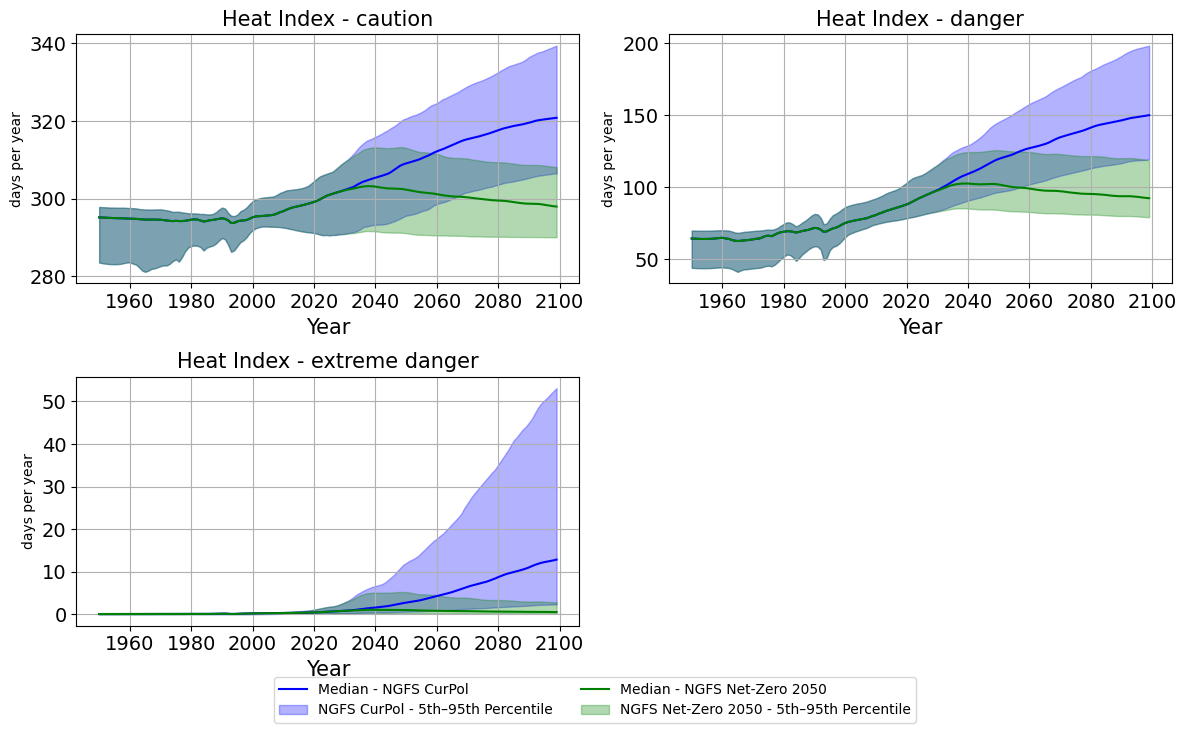

In [33]:

colors = ['blue', 'green']
tick_interval = 20

# Quantiles for plotting
low_quantile = 0.05
high_quantile = 1 - low_quantile

# plot
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))
axs = axs.flatten()

for ind_index, ind in enumerate(indicator_list):

    ax = axs[ind_index]

    for scen_index, scen in enumerate(scenario_list):

        # select variable from multi-indexed dataset
        da = all_data[ind].sel(scenario=scen)

        years = da['year']

        median = da.sel(quantile=0.5)
        low = da.sel(quantile=low_quantile)
        high = da.sel(quantile=high_quantile)

        # line
        ax.plot(
            years,
            median,
            label=f'Median - {scen}',
            color=colors[scen_index]
        )

        # uncertainty shading
        ax.fill_between(
            years,
            low,
            high,
            color=colors[scen_index],
            alpha=0.3,
            label=f'{scen} - {int(low_quantile*100)}th–{int(high_quantile*100)}th Percentile'
        )

    # labels / formatting
    ax.set_xlabel('Year', fontsize=15)
    ax.tick_params(axis='both', labelsize=14)

    if ind in [
        'HI-caution',
        'HI-danger',
        'fwixd',
        'heavy_precipitation_days',
        'HI-caution-QDM-v1',
        'HI-danger-QDM-v1',
        'HI-extreme-danger-QDM-v1'
    ]:
        ax.set_ylabel('days per year')

    elif ind in ['extreme_drought']:
        ax.set_ylabel('area affected (%)')

    if country == state:
        ax.set_title(f'{ind_names[ind]}', fontsize=15)
    else:
        ax.set_title(f'{ind} - {state} ({country})')

    ax.grid(True)
    ax.xaxis.set_major_locator(MultipleLocator(tick_interval))

# remove empty panels if needed
for i in range(len(indicator_list), len(axs)):
    fig.delaxes(axs[i])

# shared legend
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()
plt.show()

# Run dem4cli and lifetime exposure

In [ ]:
# load life expectancy data and clean 
# go from 'period' to 'cohort' life expectancy

data_dir = os.path.join('../..', 'data-dem4cli/data') # location of dem4cli data directory
filepath_lifeexpectancy = os.path.join(data_dir, 'life-expectancy/UN_WPP2024/WPP2024_MORT_F05_1_LIFE_EXPECTANCY_BY_AGE_BOTH_SEXES.xlsx') # location of UNWPP life expectancy data

df_unwpp = load_unwpp_lifeexpectancy(filepath_lifeexpectancy = filepath_lifeexpectancy) 
df_life_expectancy_5 = get_life_expectancies(df_unwpp,
                                        start_birthyear=1950,
                                        end_birthyear=2025)

load_unwpp_lifeexpectancy took 58.06 s
get_life_expectancies took 0.01 s


In [42]:
df_life_expectancy_5

Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Wallis and Futuna Islands,Western Sahara,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,73.0935,78.4736,60.3326,71.0196,72.9259,73.986,73.5868,...,76.9994,71.5994,62.5983,68.7405,68.7827,60.0066,58.8167,63.0338,68.3711,67.5054
1951,54.9914,73.117,59.9968,73.3142,78.7848,60.4601,71.3453,73.1271,74.8442,73.7835,...,77.1543,71.7428,63.0074,69.2576,69.2194,60.2678,59.0545,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,73.5873,79.0685,60.5222,71.6498,73.3441,74.3825,73.9763,...,77.303,71.891,63.3789,69.761,69.5801,60.5338,59.2911,63.3482,68.714,67.9825
1953,55.6465,75.0774,59.7686,74.0095,79.449,60.5925,71.9511,73.5912,75.4063,74.1662,...,77.4524,72.0515,63.7587,70.2772,69.953,60.8083,59.5263,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,74.5568,79.7661,60.6646,72.3025,73.8626,75.209,74.3545,...,77.5948,72.2161,64.1316,70.8107,70.2969,61.0874,59.7591,63.7344,69.1736,68.4717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,86.7605,84.3678,79.983,90.9386,75.3352,86.2771,84.7939,84.5935,82.9247,...,85.1394,79.8067,79.167,80.2522,82.4702,86.024,79.8237,78.3779,76.2603,72.3912
2022,76.441,86.923,84.5161,80.1066,91.0655,75.4478,86.4557,84.9577,84.7182,83.0688,...,85.2944,79.9032,79.3171,80.3761,82.5996,86.1649,79.9495,78.4595,76.3663,72.6039
2023,76.5566,87.0848,84.6631,80.2251,91.1889,75.5534,86.6262,85.1138,84.8523,83.2152,...,85.4518,80.0172,79.4741,80.4974,82.723,86.2609,80.0731,78.5283,76.4686,72.8116


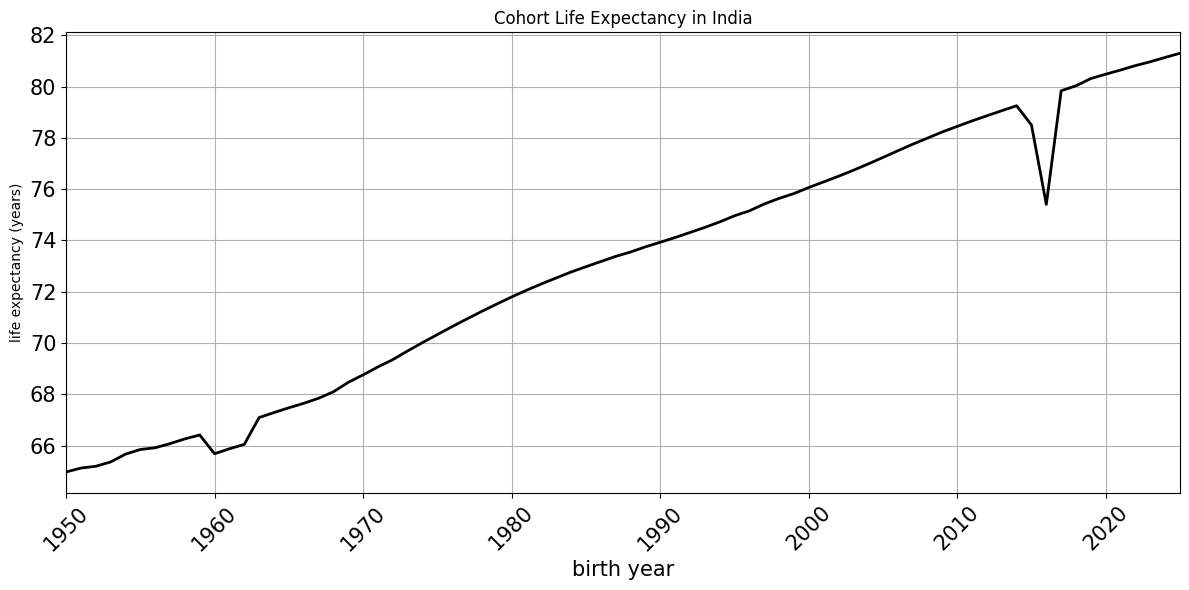

In [43]:
# Extract life expectancy data for the country of interest
life_expectancy_country = df_life_expectancy_5[country]

# Create a plot
plt.figure(figsize=(12, 6))

# Plot the life expectancy over the years
plt.plot(life_expectancy_country.index, life_expectancy_country.values,
         color='black', linewidth=2)

# Customize the plot
plt.title(f'Cohort Life Expectancy in {country}')
plt.xlabel('birth year', fontsize=15)
plt.ylabel('life expectancy (years)')
plt.grid(True)
plt.xticks(ticks=range(life_expectancy_country.index.min(), life_expectancy_country.index.max() + 1, 10),
           rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(life_expectancy_country.index.min(), life_expectancy_country.index.max())

# Show the plot
plt.tight_layout()
plt.show()

## calculate lifetime exposure

In [72]:
ds_lifetime_exp = calc_lifetime_exposure_rimex(
    all_data,
    df_life_expectancy_5,
    1950,
    2025,
    country
)

Note: max death year (2106) > max year in RIME-x quantiles (2099)


In [73]:
ds_lifetime_exp

<xarray.Dataset> Size: 26kB
Dimensions:                   (birth_year: 76, scenario: 2, quantile: 7)
Coordinates:
  * birth_year                (birth_year) int64 608B 1950 1951 ... 2024 2025
  * scenario                  (scenario) object 16B 'NGFS CurPol' 'NGFS Net-Z...
  * quantile                  (quantile) float64 56B 0.5 0.05 0.1 ... 0.9 0.95
Data variables:
    HI-caution-QDM-v1         (birth_year, scenario, quantile) object 9kB 191...
    HI-danger-QDM-v1          (birth_year, scenario, quantile) object 9kB 453...
    HI-extreme-danger-QDM-v1  (birth_year, scenario, quantile) object 9kB 10....

In [74]:
# Convert lifetime exposure from cumulated days to cumulated years

ds_lifetime_exp_toplot = xr.Dataset()

for ind in indicators:
    should_not_divide = ind_annual_bool[ind]
    if not should_not_divide:
        ds_lifetime_exp_toplot[ind] = ds_lifetime_exp[ind] / 365.25
    else:
        ds_lifetime_exp_toplot[ind] = ds_lifetime_exp[ind]

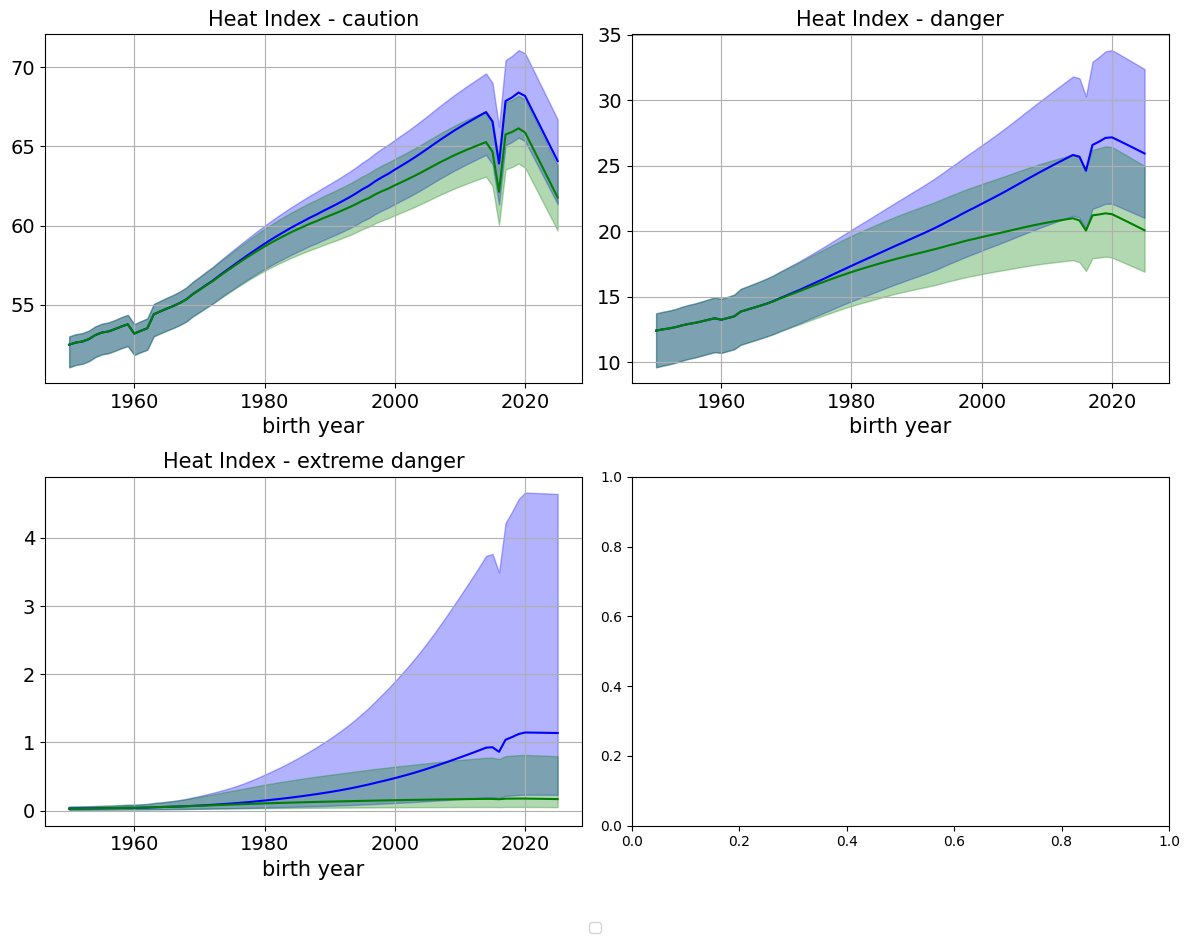

In [75]:
colors = ['blue', 'green']
tick_interval = 20

low_q = 0.05
mid_q = 0.5
high_q = 0.95

scenario_list = ds_lifetime_exp_toplot.scenario.values
indicator_list = list(ds_lifetime_exp_toplot.data_vars)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
#fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
#fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 7))
axs = axs.flatten() if len(indicators) > 1 else [axs]

for ind_idx, ind in enumerate(indicator_list):
    da = ds_lifetime_exp_toplot[ind]

    for scen_idx, scen in enumerate(scenario_list):

        # Select quantiles
        median = da.sel(scenario=scen, quantile=mid_q).values
        low = da.sel(scenario=scen, quantile=low_q).values
        high = da.sel(scenario=scen, quantile=high_q).values
        birth_years = da.birth_year.values

        # Convert to float64 arrays
        median = np.array(median, dtype=np.float64)
        low = np.array(low, dtype=np.float64)
        high = np.array(high, dtype=np.float64)

        # Plot median
        axs[ind_idx].plot(
            birth_years,
            median,
            color=colors[scen_idx],
            label=f'Median – {scen}'
        )

        # Fill uncertainty range
        axs[ind_idx].fill_between(
            birth_years,
            low,
            high,
            color=colors[scen_idx],
            alpha=0.3,
            label=f'{scen}: {int(low_q*100)}–{int(high_q*100)}%'
        )

    # Axis styling
    if country == state:
        #axs[ind_idx].set_title(f'{ind} – {country}')
        axs[ind_idx].set_title(f'{ind_names[ind]}', fontsize=15)
    else:
        axs[ind_idx].set_title(f'{ind} – {state} ({country})')
    axs[ind_idx].set_xlabel('birth year', fontsize=15)
    #axs[ind_idx].set_ylabel('lifetime exposure (years)')
    axs[ind_idx].tick_params(axis='both', labelsize=14)  # Increase tick label font size
    axs[ind_idx].grid(True)
    axs[ind_idx].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Shared legend (column legend)
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.show()